In [ ]:
import scanpy as sc
import decoupler as dc
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import colors
from matplotlib.lines import Line2D

def get_dotplot_df(adata, annotation_col, genes_for_plot, expression_cutoff=0, 
                   standard_var=False, standard_method='zscore',
                   cap=None, floor=None):
    # cap / floor are quantiles (e.g. cap=0.99, floor=0.01)

    import numpy as np
    import scipy.sparse as sp
    import pandas as pd
    from scipy.stats import zscore

    # filter the anndata by genes needed for plot
    ad = adata[:, adata.var_names.isin(genes_for_plot)].copy()

    # ensure dense matrix for manipulation
    X = ad.X.toarray() if sp.issparse(ad.X) else ad.X.copy()

    # --- NEW: apply per-gene clipping ---
    if cap is not None or floor is not None:
        for i, gene in enumerate(ad.var_names):
            gene_expr = X[:, i]

            if floor is not None:
                floor_value = np.quantile(gene_expr, floor)
            else:
                floor_value = gene_expr.min()

            if cap is not None:
                cap_value = np.quantile(gene_expr, cap)
            else:
                cap_value = gene_expr.max()

            X[:, i] = np.clip(gene_expr, floor_value, cap_value)

    # convert to df
    df = pd.DataFrame(
        X,
        index=[ad.obs['cell_id'], ad.obs[annotation_col]],
        columns=ad.var_names
    )

    # get mean per group
    group_mean = df.reset_index().drop('cell_id', axis=1)\
        .groupby(annotation_col, observed=True).mean()

    # normalise/standardise the group mean
    if standard_var:
        if standard_method == 'zscore':
            group_mean = group_mean.apply(zscore, axis=0)
        elif standard_method == 'minmax':
            group_mean = (group_mean - group_mean.min(axis=0)) / (
                group_mean.max(axis=0) - group_mean.min(axis=0)
            )

    # melt df for plotting
    group_mean = group_mean.melt(ignore_index=False, var_name="feature")\
        .reset_index().set_index([annotation_col, 'feature'])\
        .rename(columns={'value': 'mean'})

    # calculate cell fraction
    cell_fraction = (df > expression_cutoff).reset_index()\
        .drop('cell_id', axis=1)\
        .groupby(annotation_col, observed=True).sum().divide(
            df.reset_index().groupby(annotation_col, observed=True)['cell_id'].count(),
            axis=0
        )\
        .melt(ignore_index=False, var_name="feature")\
        .reset_index().set_index([annotation_col, 'feature'])\
        .rename(columns={'value': 'proportion'})

    # return concatenated mean and fraction
    return pd.concat([group_mean, cell_fraction], axis=1).reset_index()

reference_dir = '../../../data/GBM_LEAP_annotations/'
output_dir = '../../../data/Fig1/'

paper_order = [
    "OPC-like 4",
    "OPC-NPC-like 2",
    "OPC-NPC-like 1",
    "OPC-like 3",
    "OPC-like 1",
    "OPC-like 2",
    "OPC-NPC-like 3",
    "OPC-like 5",
    "OPC-neuronal-like",
    "NPC-neuronal-like 2",
    "NPC-neuronal-like 1",
    "NPC-neuronal-like 4",
    "NPC-neuronal-like 5",
    "NPC-neuronal-like 3",
    "AC-gliosis-like 4",
    "AC-gliosis-like 2",
    "Hypoxic 1",
    "Gliosis-like",
    "AC progenitor-like 3",
    "AC progenitor-like 1",
    "AC-gliosis-like 1",
    "AC progenitor-like 4",
    "AC-gliosis-like 3",
    "Hypoxic 2",
    "AC progenitor-like 2",
    'Proliferative AC-OPC-like',
    'Proliferative NPC-OPC-like',
    'Proliferative nIPC-like'
]

mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
adata = sc.read_h5ad(os.path.join(reference_dir, 'GBM_LEAP_annotations_v2.22_04_25.webatlas.h5ad'))
adata = adata[adata.obs['cell_status']=='Malignant']
adata = adata[:,adata.var['feature_types']=='Gene Expression']

# normalise
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Neftel scores

In [ ]:
from scipy import stats

# get neftel scores
neftel_score_list = []
modules = pd.read_csv('../data/metadata/neftel_module_scores.csv')
for i in modules.columns:
    gene_list = modules[i].dropna().tolist()
    sc.tl.score_genes(adata, gene_list, score_name=i+'_score', use_raw=False)
    neftel_score_list.append(i+'_score')
neftel_score_list = [i for i in neftel_score_list if '/' not in i]

neftel_scores = adata.obs[neftel_score_list+['annotation_granular']]
neftel_scores['neftel_top'] = neftel_scores[neftel_score_list].idxmax(axis=1)
neftel_scores = neftel_scores.groupby('annotation_granular')['neftel_top'].value_counts().reset_index()
neftel_scores = neftel_scores.pivot(index = 'annotation_granular', columns = 'neftel_top', values = 'count')
neftel_scores = neftel_scores.divide(neftel_scores.sum(axis=1), axis=0)

/tmp/ipykernel_3911980/1340572783.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neftel_scores['neftel_top'] = neftel_scores[neftel_score_list].idxmax(axis=1)
/tmp/ipykernel_3911980/1340572783.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  neftel_scores = neftel_scores.groupby('annotation_granular')['neftel_top'].value_counts().reset_index()


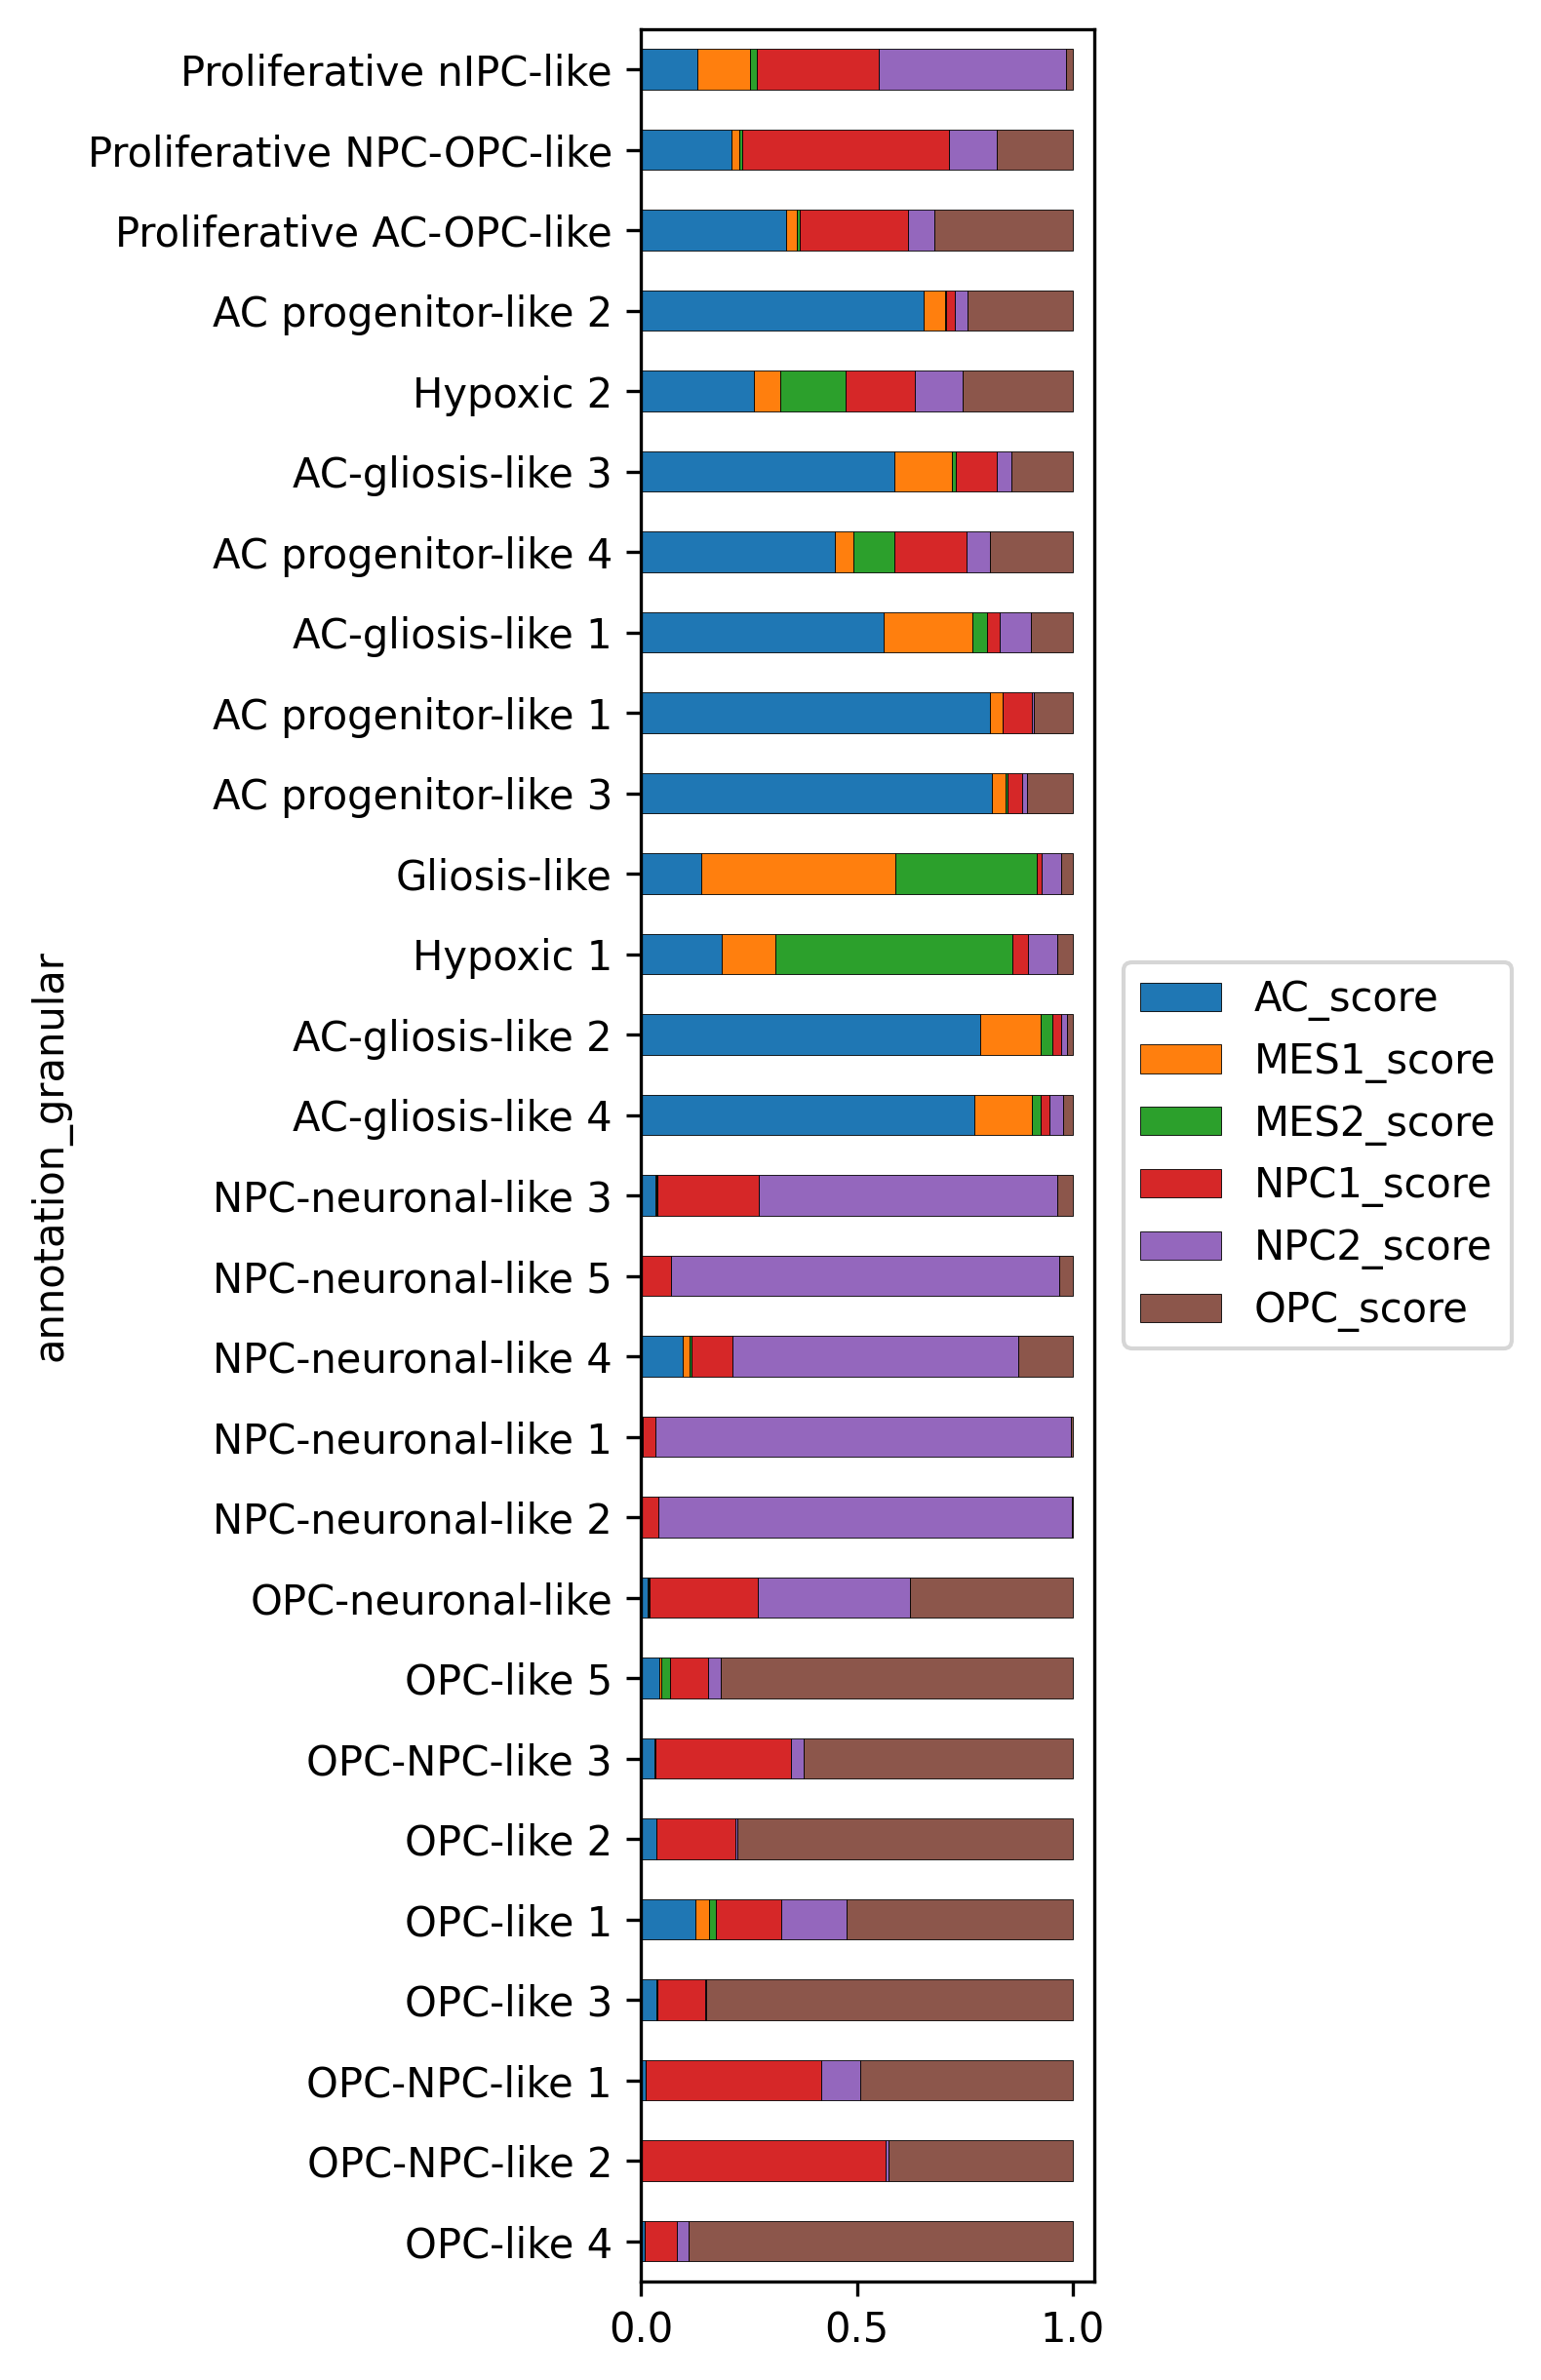

In [ ]:
neftel_scores = neftel_scores.reindex(paper_order)
ax = neftel_scores.plot.barh(figsize=(2, 10), 
                             edgecolor="black",
                             linewidth=0.2,
                             stacked=True)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.savefig('../annotation_plots/Fig1c1.pdf')

neftel_scores.to_csv(f'{output_dir}/Fig1c1.csv')

# Tumour composition

In [ ]:
tumour_comp = adata.obs.groupby('annotation_granular')['donor_id'].value_counts().reset_index()
tumour_comp = tumour_comp.pivot(index = 'annotation_granular', columns = 'donor_id', values = 'count')
tumour_comp = tumour_comp.divide(tumour_comp.sum(axis=1), axis=0)

/tmp/ipykernel_4091993/3837109426.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tumour_comp = adata.obs.groupby('annotation_granular')['donor_id'].value_counts().reset_index()


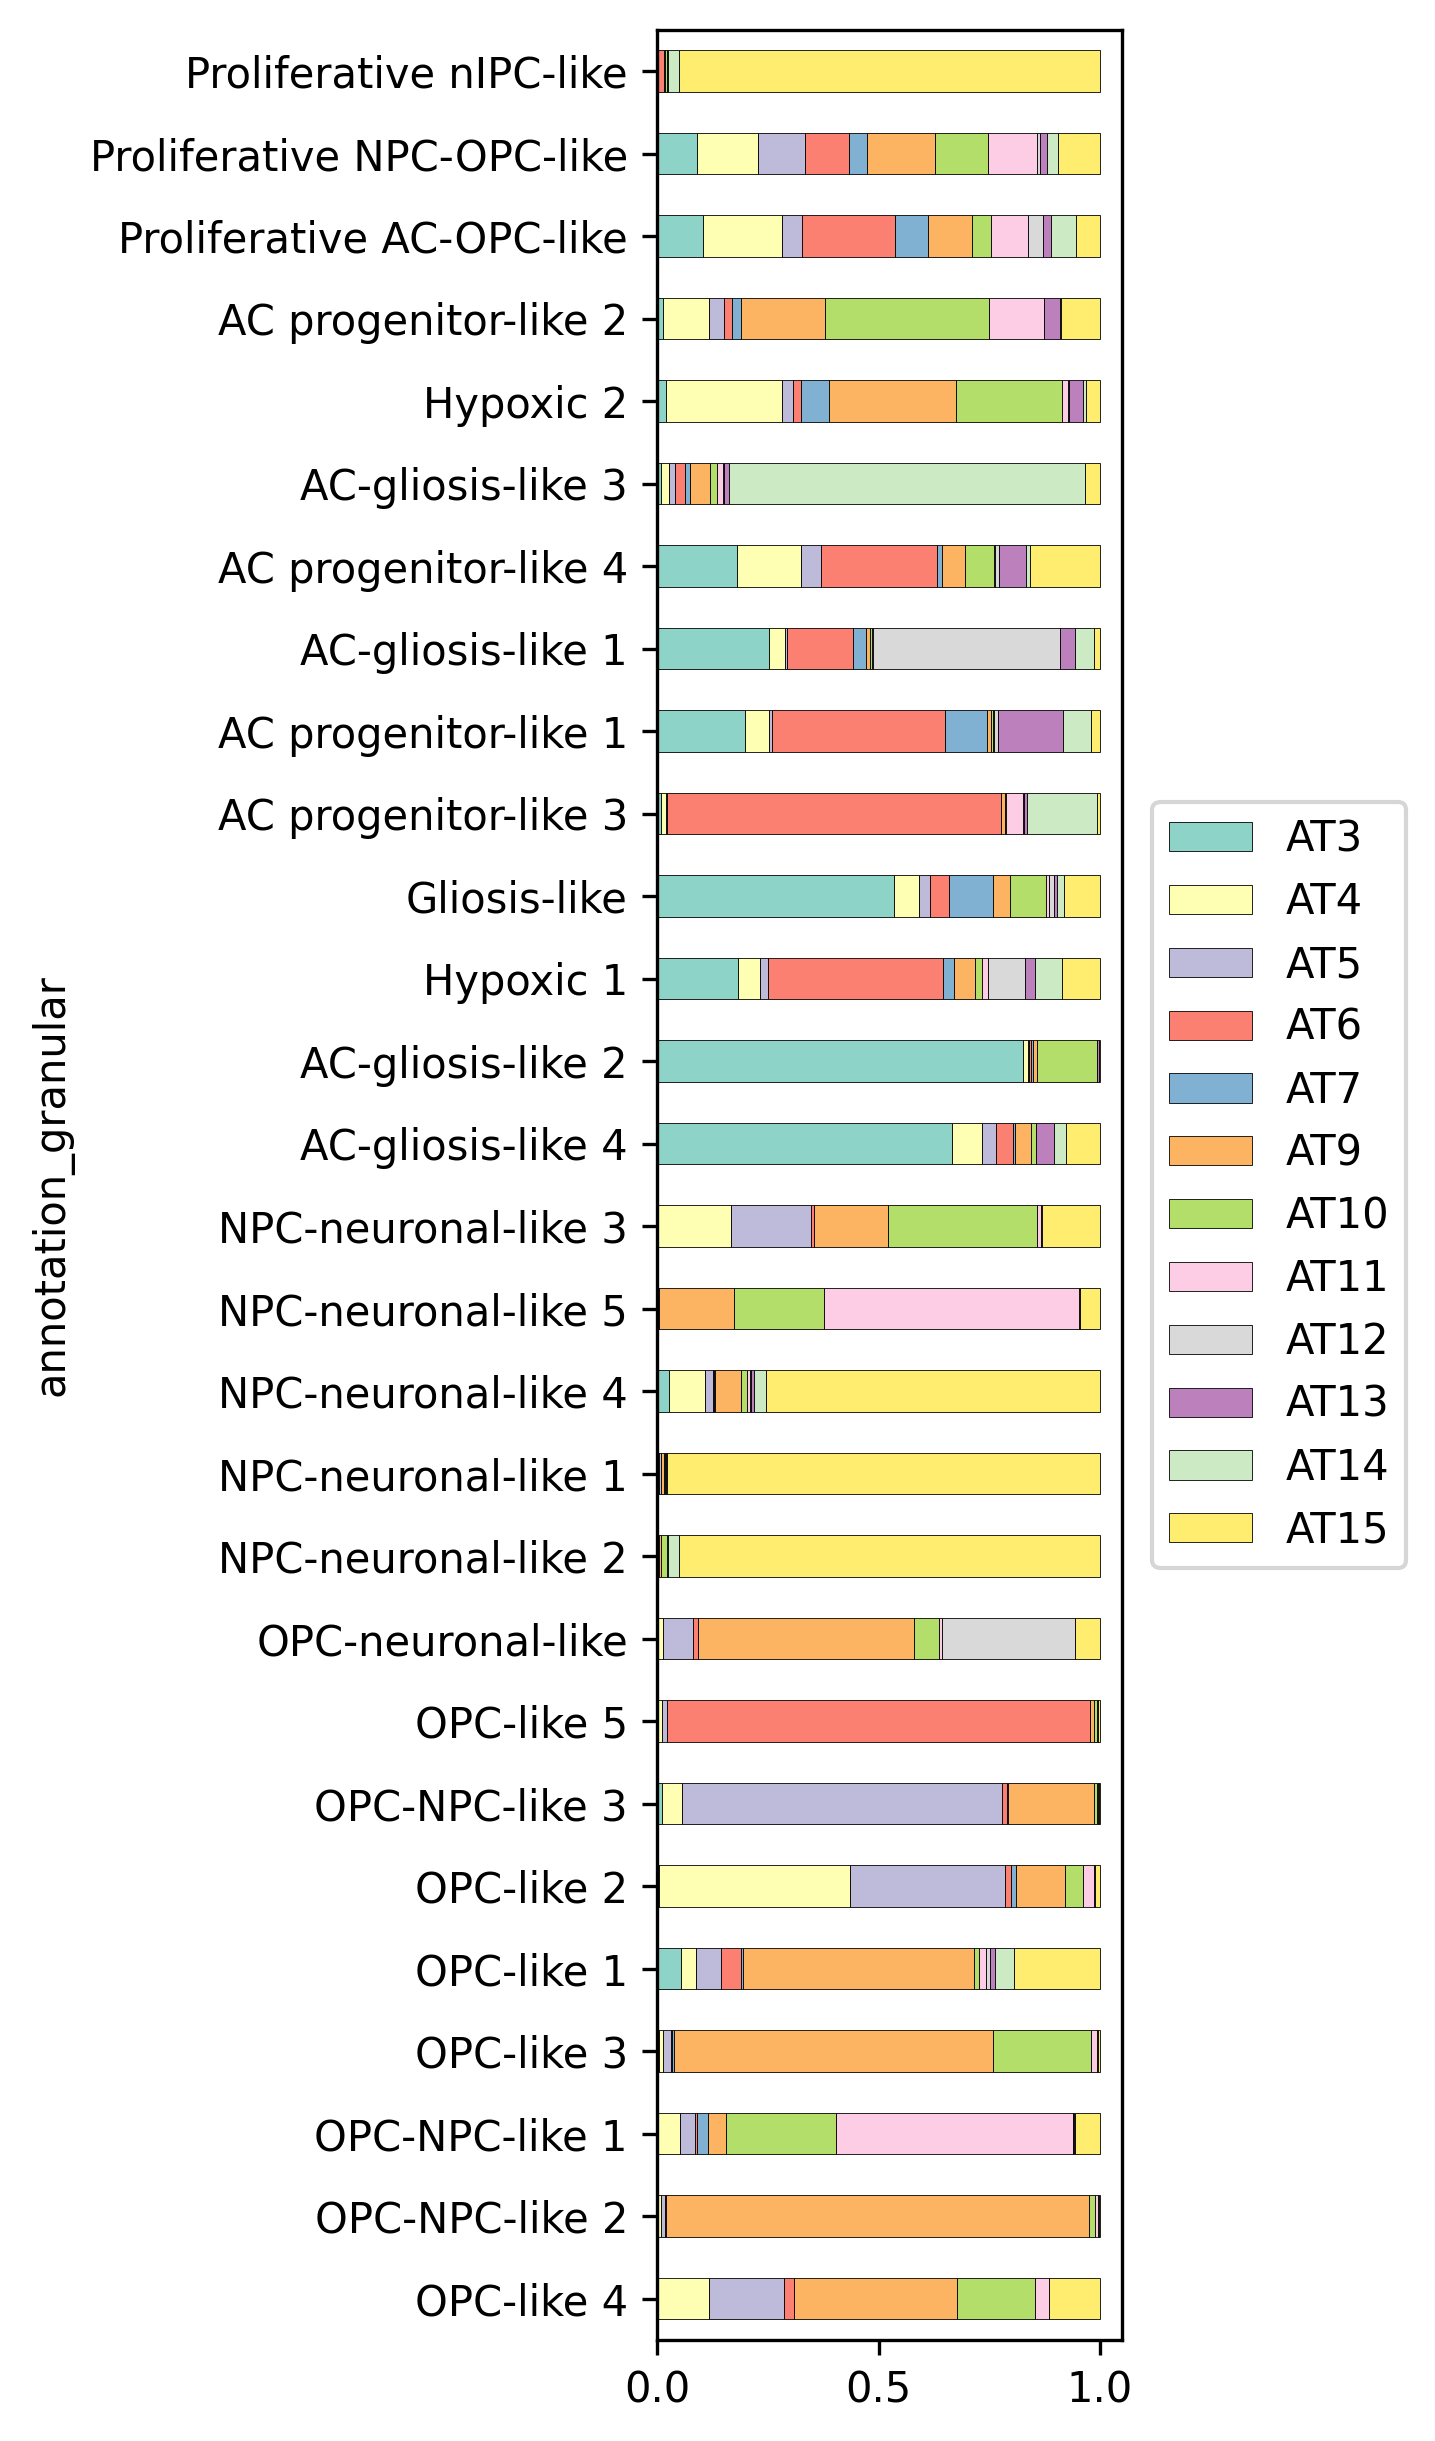

In [ ]:
tumour_comp = tumour_comp.reindex(paper_order)

ax = tumour_comp.plot.barh(figsize=(2, 10), 
                           edgecolor="black",
                           linewidth=0.2,
                           stacked=True,
                           cmap = 'Set3'
)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.savefig('../annotation_plots/Fig1c2.pdf')

tumour_comp.to_csv(f'{output_dir}/Fig1c2.csv')

# Gene expression

In [ ]:
genes = [
    "OLIG1",
    "GRID2",
    "SOX6",
    "PDGFRA",
    "DSCAM",
    "GRIA4",
    "GRIK2",
    "DLL3",
    "MYT1L",
    "DCX",
    "SOX11",
    "STMN2",
    "RBFOX3",
    "RYR3",
    "GFAP",
    "SLC1A3",
    "SERPINE1",
    "VIM",
    "VEGFA",
    "HILPDA",
    "MKI67",
    "CENPF",
]

In [ ]:
dp_df = get_dotplot_df(
    adata,
    'annotation_granular',
    genes,
    standard_var=True,
    standard_method='zscore',
    cap=1,
    floor=0
)

In [ ]:
dp_df["annotation_granular"] = pd.Categorical(
    dp_df["annotation_granular"],
    categories=paper_order,
    ordered=True
)

dp_df["feature"] = pd.Categorical(
    dp_df["feature"],
    categories=genes,
    ordered=True
)

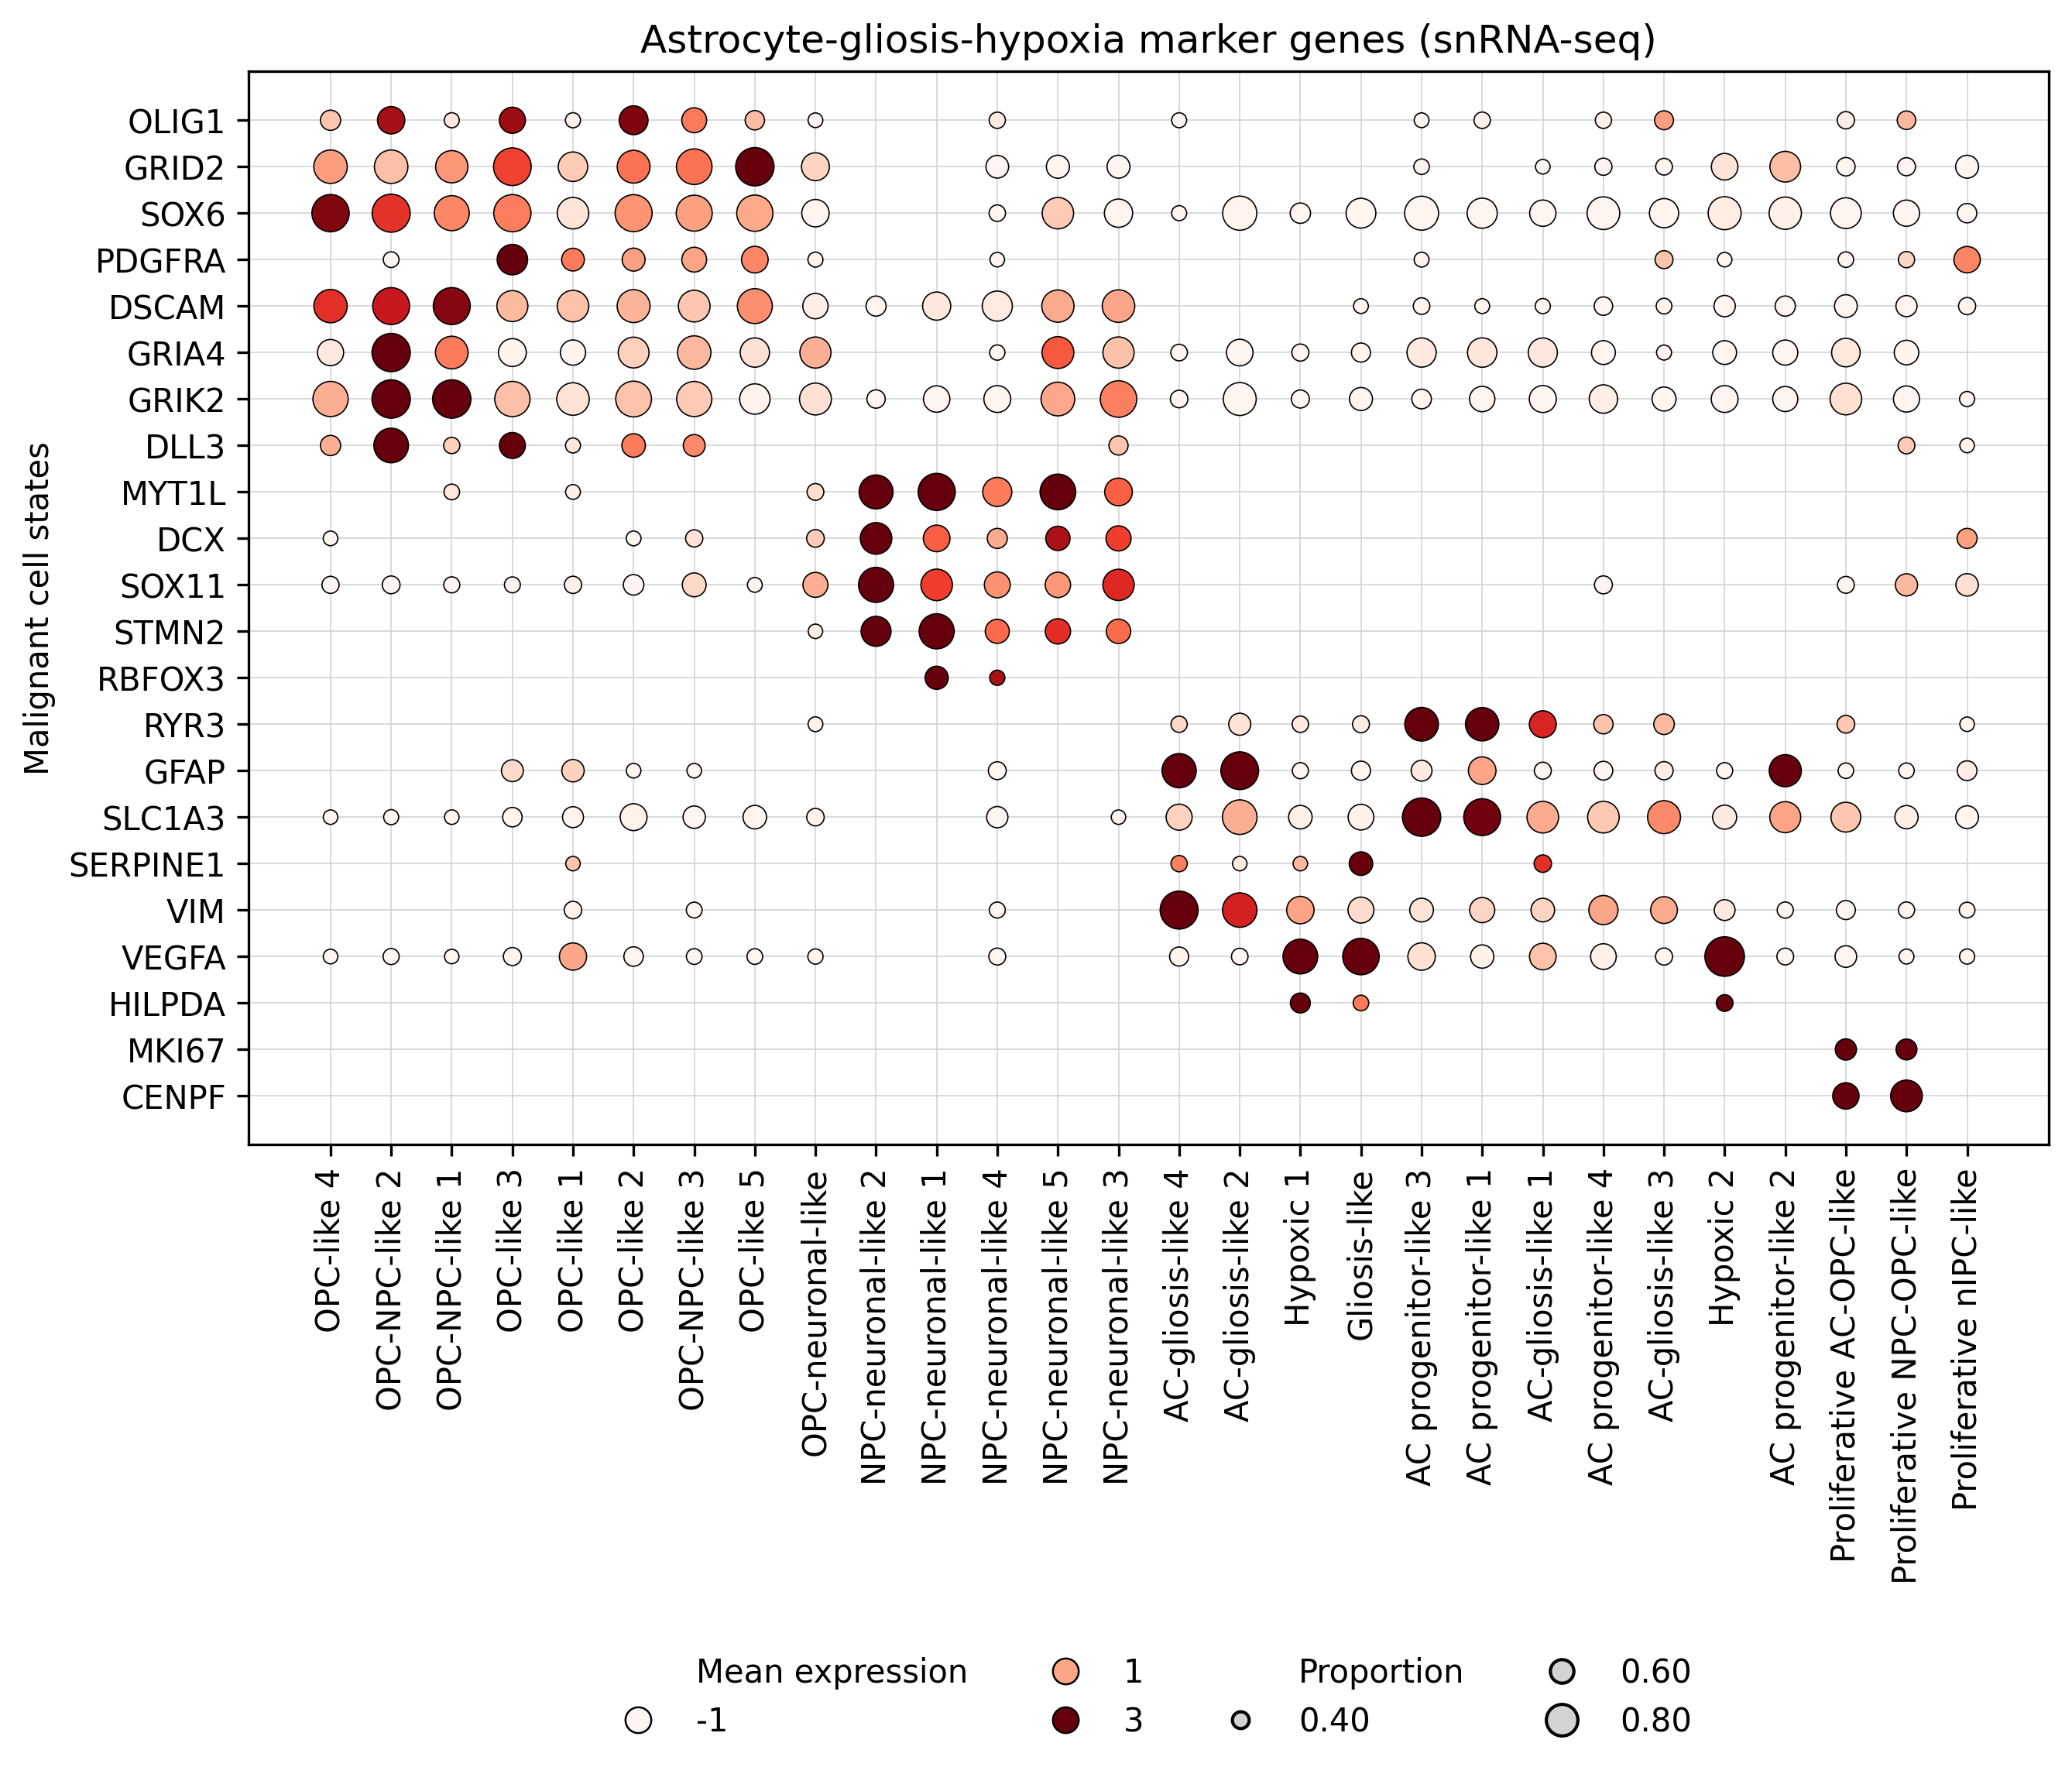

In [ ]:
# --- FILTER: drop low-proportion dots ---
dp_df_plot = dp_df[dp_df['proportion'] >= 0.25].copy()

# Color scaling
vmax = np.quantile(dp_df_plot['mean'], 0.99)
norm = colors.TwoSlopeNorm(vmin=0, vcenter=1.6, vmax=2)
cmap = plt.get_cmap('Reds')

# --- Dot-size scaling ---
size_min, size_max = 20, 150
pmin, pmax = dp_df_plot['proportion'].min(), dp_df_plot['proportion'].max()

prop_scaled = (dp_df_plot['proportion'] - pmin) / (pmax - pmin)
prop_scaled = np.clip(prop_scaled, 0, 1)
size_exp = 1.8

dp_df_plot['dot_area'] = size_min + (size_max - size_min) * (prop_scaled ** size_exp)

plt.figure(figsize=(10, 6))

ax = sns.scatterplot(
    data=dp_df_plot,
    y='feature',
    x='annotation_granular',
    hue='mean',
    size='dot_area',
    sizes=(size_min, size_max),
    palette='Reds',
    hue_norm=norm,
    edgecolor='black',
    linewidth=0.4,
    legend=False
)

# Grid lines
ax.set_axisbelow(True)
ax.grid(True, axis='x', color='lightgrey', linewidth=0.4)
ax.grid(True, axis='y', color='lightgrey', linewidth=0.4)

plt.xticks(rotation=90)
plt.title('Astrocyte-gliosis-hypoxia marker genes (snRNA-seq)')

# --- COLOR LEGEND ---
color_values = [-1, 1, 3]
color_handles = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        markersize=8,
        markerfacecolor=cmap(norm(v)),
        markeredgecolor='black',
        markeredgewidth=0.6,
        label=f'{v:g}'
    )
    for v in color_values
]

# --- SIZE LEGEND ---
size_values = [0.4, 0.6, 0.8]
size_handles = []
for v in size_values:
    v_scaled = (v - pmin) / (pmax - pmin)
    v_scaled = np.clip(v_scaled, 0, 1)
    area = size_min + (size_max - size_min) * (v_scaled ** size_exp)
    size_handles.append(
        Line2D(
            [0], [0],
            marker='o',
            linestyle='',
            markersize=np.sqrt(area),
            markerfacecolor='lightgrey',
            markeredgecolor='black',
            label=f'{v:.2f}'
        )
    )

# Combine legends
handles = (
    [Line2D([], [], linestyle='', label='Mean expression')] +
    color_handles +
    [Line2D([], [], linestyle='', label='Proportion')] +
    size_handles
)

labels = [h.get_label() for h in handles]

ax.legend(
    handles,
    labels,
    bbox_to_anchor=(0.5, -0.45),
    loc='upper center',
    ncol=4,
    frameon=False
)

ax.set_xlabel('')
ax.set_ylabel('Malignant cell states')

plt.savefig('../annotation_plots/Fig1c3.pdf')
dp_df.to_csv(f'{output_dir}/Fig1c3.csv')

# decoupler + MSigDB

In [ ]:
adata = adata[:, ~adata.var_names.duplicated()].copy()

In [ ]:
## get DEGs

sc.tl.rank_genes_groups(
    adata,
    groupby="annotation_granular",
    method="wilcoxon"
)
deg = sc.get.rank_genes_groups_df(adata, group=None)
deg.to_csv(os.path.join(output_dir, 'Fig1c_degs.csv'))

In [ ]:
# load if finished
deg = pd.read_csv(os.path.join(output_dir, 'Fig1c_degs.csv'), index_col=0)

In [ ]:
## get HVGs for malignant cells

sc.pp.highly_variable_genes(adata, 
                            min_mean=0.0075, 
                            max_mean=4, 
                            min_disp=0.1,
                            batch_key="donor_id"
)
selected = adata.var['highly_variable']

In [ ]:
# get resources
msigdb = dc.get_resource("MSigDB")

collections = [
    "go_biological_process",
    "hallmark",
    "kegg_pathways",
    "cell_type_signatures"
]

net = (
    msigdb[msigdb["collection"].isin(collections)]
    [["geneset", "genesymbol"]]
    .drop_duplicates()
)

In [ ]:
geneset_size = net.groupby("geneset").size()
gsea_genesets = geneset_size.index[(geneset_size > 15) & (geneset_size < 500)]

In [ ]:
t_stats_all = {}
for state in set(deg['group']):
    # extract scores
    t_stats = (
        # Get dataframe of DE results for condition vs. rest
        deg[deg['group']==state]\
        # Subset to highly variable genes
        .set_index("names")
        .loc[selected]
        # Sort by absolute score
        .sort_values("scores", key=np.abs, ascending=False)
        # Format for decoupler
        [["scores"]]
        .rename_axis([state], axis=1)
    )
    t_stats_all[state] = t_stats

In [ ]:
gsea_results_all = {}
for state in set(deg['group']):
    print(state)
    scores, norm, pvals = dc.run_gsea(
        t_stats_all[state].T,
        net[net["geneset"].isin(gsea_genesets)],
        source="geneset",
        target="genesymbol",
    )
    gsea_results = (
        pd.concat({"score": scores.T, "norm": norm.T, "pval": pvals.T}, axis=1)
        .droplevel(level=1, axis=1)
        .sort_values("pval")
    )
    gsea_results.to_csv(os.path.join(output_dir, 'GSEA', '{}_gsea_results.txt'.format(state)), sep = '\t')
    gsea_results_all[state] = gsea_results

AC progenitor-like 2


# decoupler plotting

In [ ]:
deg = pd.read_csv(os.path.join(output_dir, 'Fig1c_degs.csv'), index_col=0)

gsea_results_all = {}
for state in set(deg['group']):
    gsea_results = pd.read_csv(os.path.join(output_dir, 'GSEA', '{}_gsea_results.txt'.format(state)), 
                               sep = '\t', index_col=0)
    gsea_results_all[state] = gsea_results

In [ ]:
ct = 'Gliosis-like'
(gsea_results_all[ct][gsea_results_all[ct].index.str.contains('hypoxia', case=False)]).head(20)

,score,norm,pval
source,,,
HALLMARK_HYPOXIA,0.711553,1.955621,0.000000
GOBP_NEGATIVE_REGULATION_OF_CELLULAR_RESPONSE_TO_HYPOXIA,0.863403,1.518503,0.010853
GOBP_INTRINSIC_APOPTOTIC_SIGNALING_PATHWAY_IN_RESPONSE_TO_HYPOXIA,0.813009,1.398292,0.052713
GOBP_REGULATION_OF_CELLULAR_RESPONSE_TO_HYPOXIA,0.730776,1.385595,0.071637


In [ ]:
selected_pathways = [
    'GOBP_OLIGODENDROCYTE_DIFFERENTIATION',
    'GOBP_CENTRAL_NERVOUS_SYSTEM_NEURON_DEVELOPMENT', #'GOBP_CENTRAL_NERVOUS_SYSTEM_NEURON_DIFFERENTIATION',#
    'GOBP_ASTROCYTE_DIFFERENTIATION',
    'GOBP_REGULATION_OF_WOUND_HEALING',
    'HALLMARK_HYPOXIA',
    'GOBP_REGULATION_OF_NUCLEAR_DIVISION'
]

In [ ]:
filtered_pathway_df = []
for ct in gsea_results_all:
    res = gsea_results_all[ct][gsea_results_all[ct].index.isin(selected_pathways)].copy()
    res['state'] = ct
    filtered_pathway_df.append(res)
filtered_pathway_df = pd.concat(filtered_pathway_df).reset_index()

p_floor = 1 / (2e3 + 1)

filtered_pathway_df["pval_plot"] = (
    filtered_pathway_df["pval"]
    .clip(lower=p_floor)
)
filtered_pathway_df["ng_log_p"] = -np.log(
    filtered_pathway_df["pval_plot"]
)

In [ ]:
filtered_pathway_df["state"] = pd.Categorical(
    filtered_pathway_df["state"],
    categories=paper_order,
    ordered=True
)

filtered_pathway_df["source"] = pd.Categorical(
    filtered_pathway_df["source"],
    categories=selected_pathways,
    ordered=True
)


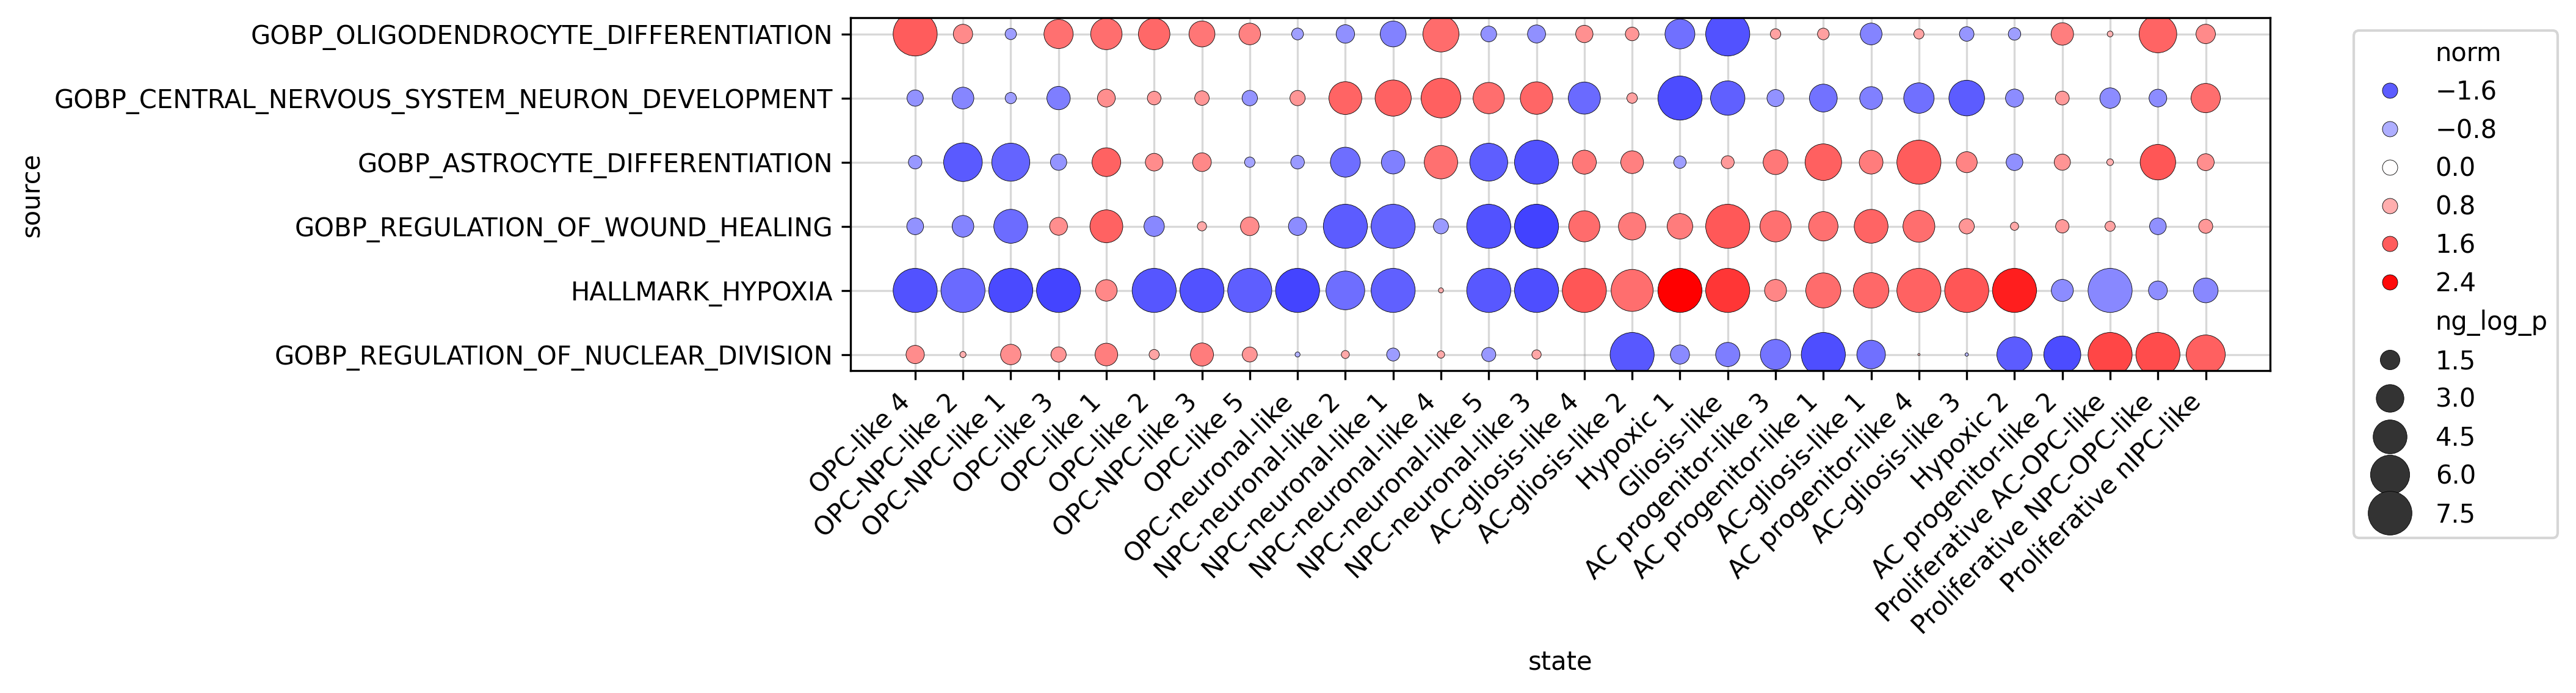

In [ ]:
plt.figure(figsize=(10, 2.5))
ax = sns.scatterplot(data = filtered_pathway_df, x = 'state', y = 'source',
                hue = 'norm', size = 'ng_log_p', 
                linewidth = 0.2, edgecolor = 'black',
                palette = 'bwr', #'RdBu_r', 
                sizes=(0, 300), hue_norm = (-2.5, 2.5))
plt.xticks(rotation=45, ha="right")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
ax.grid(True, color="grey", alpha=0.3, zorder=-1)
ax.set_axisbelow(True)
plt.savefig('../annotation_plots/Fig1c4.pdf')


In [ ]:
filtered_pathway_df.to_csv(os.path.join(output_dir, 'Fig1c4_GSEA.csv'))

# Tumour location plots

In [ ]:
# map to cell classes
cell_classes = {
    'AC-gliosis-like':'AC-gliosis-hypoxia',
    'AC-progenitor-like':'AC-gliosis-hypoxia',
    'Gliosis-like':'AC-gliosis-hypoxia',
    'Hypoxic':'AC-gliosis-hypoxia',
    'NPC-neuronal-like':'NPC-neuronal-like',
    'OPC-NPC-like':'NPC-OPC-like',
    'OPC-like':'NPC-OPC-like',
    'OPC-neuronal-like':'NPC-OPC-like',
    'Proliferative':'Proliferative'
}

plot_df = adata.obs[['donor_id', 'site_id', 'annotation_coarse']]
plot_df['cell_class'] = plot_df['annotation_coarse'].map(cell_classes)
plot_df = plot_df.groupby(['donor_id', 'site_id', 'cell_class'], as_index=False,
               observed=True)['annotation_coarse'].value_counts()
plot_df = plot_df[plot_df['count']>0]

plot_df.to_csv(os.path.join(output_dir, 'Fig1d_cell_state_identities.csv'))

In [ ]:
plot_df = pd.read_csv(os.path.join(output_dir, 'Fig1d_cell_state_identities.csv'), index_col=0)

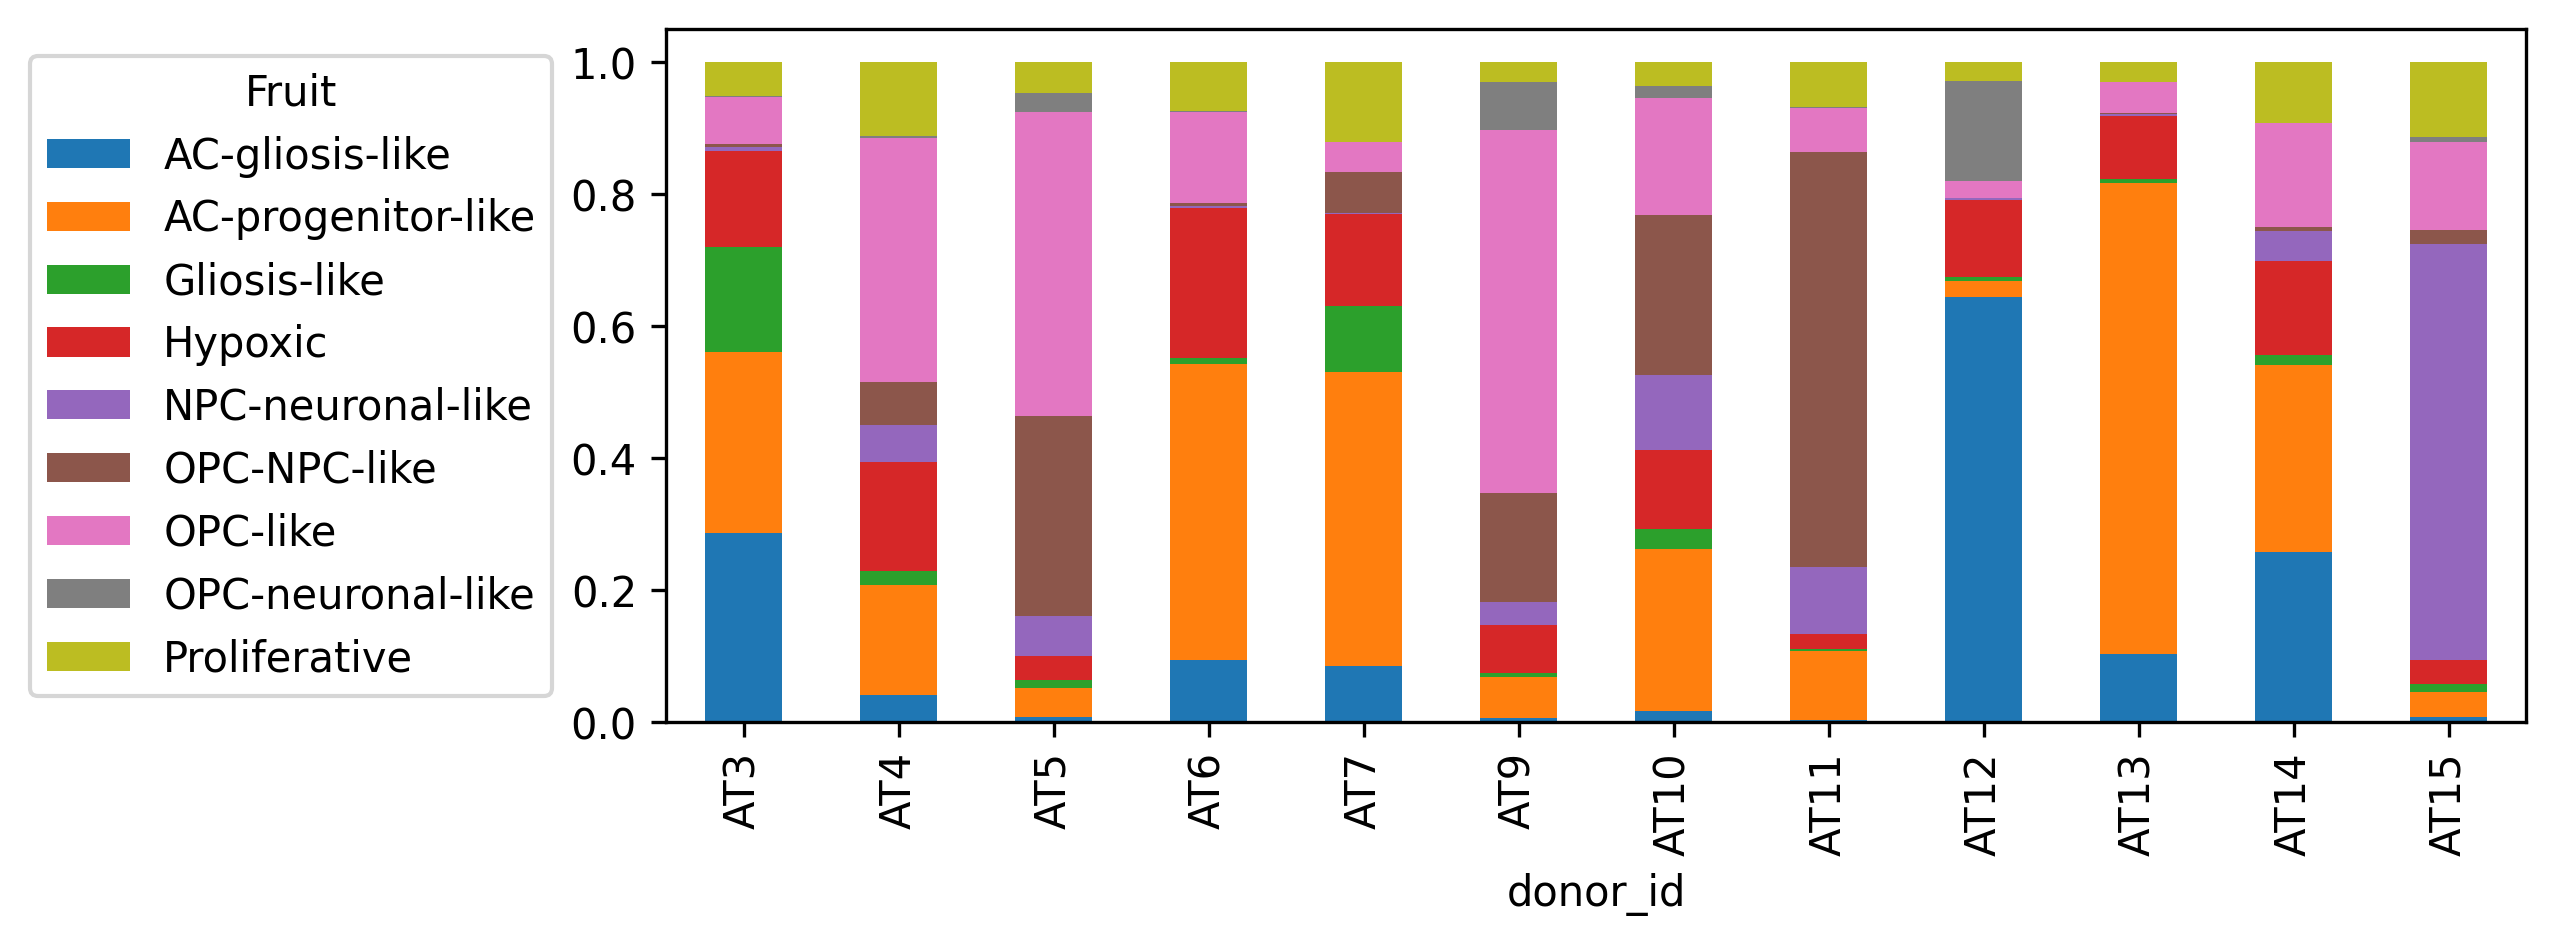

In [ ]:
p1 = plot_df.groupby(['donor_id', 'annotation_coarse'], as_index=False)['count'].sum()\
    .pivot(index = 'donor_id', columns = 'annotation_coarse', values = 'count')
p1 = p1.reindex(['AT3', 'AT4', 'AT5','AT6', 'AT7', 'AT9', 'AT10', 
                 'AT11', 'AT12', 'AT13', 'AT14', 'AT15'])
ax = p1.divide(p1.sum(axis=1), axis=0)\
    .plot(
    kind="bar",
    stacked=True,
    figsize=(8, 3),
)
ax.legend(
    title="Fruit",
    loc="center right",
    bbox_to_anchor=(-0.05, 0.5)
)
plt.show()